# COMP47590: Advanced Machine Learning
## Assignment 1: Pet Classification

Modern deep learning methods make accurate image classification for a huge range of problems easily accessible. In this assignment you will be tasked with building and evaluating different types of image classification models for the [Oxford-IIIT Pet Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/). This starter notebook puts in place data loaders to use for this assignment.

- Student 1 Name: Hiew Reid-Ken
- Student 1 Number: 25201555
- Student 2 Name:
- Student 2 Number:
- Student 3 Name:
- Student 3 Number:

### Import Packages

In [1]:
import os, time, copy
from typing import List

import numpy as np
import matplotlib.pyplot as plt
import PIL
import collections
import random

import torch
import torch.nn as nn
from jedi.inference.gradual.typing import TypedDict
from torch.nn.modules.loss import _WeightedLoss
from torch.optim import Optimizer
import torch.utils.data 
import torchvision.datasets 
import torchvision
import torchvision.transforms
from torchvision.models import  efficientnet_v2_l, EfficientNet_V2_L_Weights

if torch.cuda.is_available():
    # CUDA only available in Nvidia Processor
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Apple will use MPS for GPU acceleration
    DEVICE = torch.device("mps" )
else:
    DEVICE = torch.device("cpu")

print(f"PyTorch version : {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
print(f"MPS available  : {torch.backends.mps.is_available()}")
print(f"Using device: {DEVICE}")

PyTorch version : 2.11.0+cu130
Torchvision version: 0.26.0+cu130
CUDA available  : True
MPS available  : False
Using device: cuda


### Dataset Setup

Setup the dataset to be used for the assignment. We use a dataset loader from `torchvision` to access `torchvision.datasets.OxfordIIITPet` as this makes data setup very straight forward. `torchvision.datasets.OxfordIIITPet` will automatically download the dataset the first time it is run.

The key parameters we use when interacting with the dataset are:
| Parameter | Description |
|-----------|-------------|
| `split` | `"trainval"` or `"test"` |
| `target_types` | `"category"`, `"binary-category"`, or `"segmentation"` |
| `transform` | Image transforms |
| `target_transform` | Label transforms |


If using Google Colab use the code below.

In [2]:
#from google.colab import drive
#drive.mount('/content/drive', force_remount=True)
#import sys
#sys.path.append('/content/drive/MyDrive/COMP47590/Assignment1/Pets/')
#ROOT_DIR = '/content/drive/MyDrive/COMP47590/Assignment1/Pets/'

Initial dataset setup (data will be downloaded). 

In [11]:
DATA_DIR = "./data"
IMAGE_SIZE = (224, 224)

# Basic transforms to apply to all data
image_transforms = torchvision.transforms.Compose([
    torchvision.transforms.Resize(IMAGE_SIZE),
    torchvision.transforms.ToTensor(),
    # these normalisation values match what was used for the Imagenet training data that we will most likely use in transfer learning
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Load the combined train and validation split
trainval_dataset = torchvision.datasets.OxfordIIITPet(
    root=DATA_DIR,
    split="trainval",
    target_types="category",   # 37 breed classes
    transform=image_transforms,
    download=True,
)

# Load the test split
test_dataset = torchvision.datasets.OxfordIIITPet(
    root=DATA_DIR,
    split="test",
    target_types="category",
    transform=image_transforms,
    download=True,
)

print(f"Trainval size : {len(trainval_dataset)}")
print(f"Test size     : {len(test_dataset)}")
print(f"Num classes   : {len(trainval_dataset.classes)}")

Trainval size : 3680
Test size     : 3669
Num classes   : 37


Print the class names from the loaded dataset.

In [12]:
class_names = trainval_dataset.classes
NUM_CLASSES = len(class_names)
print("Breed classes:")
for idx, name in enumerate(class_names):
    print(f"  {idx:2d}: {name}")

Breed classes:
   0: Abyssinian
   1: American Bulldog
   2: American Pit Bull Terrier
   3: Basset Hound
   4: Beagle
   5: Bengal
   6: Birman
   7: Bombay
   8: Boxer
   9: British Shorthair
  10: Chihuahua
  11: Egyptian Mau
  12: English Cocker Spaniel
  13: English Setter
  14: German Shorthaired
  15: Great Pyrenees
  16: Havanese
  17: Japanese Chin
  18: Keeshond
  19: Leonberger
  20: Maine Coon
  21: Miniature Pinscher
  22: Newfoundland
  23: Persian
  24: Pomeranian
  25: Pug
  26: Ragdoll
  27: Russian Blue
  28: Saint Bernard
  29: Samoyed
  30: Scottish Terrier
  31: Shiba Inu
  32: Siamese
  33: Sphynx
  34: Staffordshire Bull Terrier
  35: Wheaten Terrier
  36: Yorkshire Terrier


#### Partition Dataset

Partition the datset into training and valudation partitons using PyTorch data loaders. 

In [13]:
VAL_SPLIT_FRAC = 0.2
SEED = 42

val_size   = int(len(trainval_dataset) * VAL_SPLIT_FRAC)
train_size = len(trainval_dataset) - val_size

train_dataset, val_dataset = torch.utils.data.random_split(
    trainval_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

print(f"Train : {len(train_dataset)}")
print(f"Val   : {len(val_dataset)}")
print(f"Test  : {len(test_dataset)}")

Train : 2944
Val   : 736
Test  : 3669


#### Create Data Loaders

Create data loaders for accessing data

In [17]:
BATCH_SIZE  = 16
NUM_WORKERS = 2

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = torch.utils.data.DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)

# Quick sanity check
images, labels = next(iter(train_loader))
print(f"Batch image shape : {images.shape}")
print(f"Batch label shape : {labels.shape}")

Batch image shape : torch.Size([16, 3, 224, 224])
Batch label shape : torch.Size([16])


Define reusable methods

In [7]:
def train_epoch(model, criterion, optimizer: Optimizer):
    """Train the model for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = running_loss / total
    accuracy = 100 * correct / total

    return avg_loss, accuracy

def validate(model, criterion: _WeightedLoss):
    """Evaluate the model on validation data."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = running_loss / total
    accuracy = 100 * correct / total

    return avg_loss, accuracy

def train(
    model: nn.Module,
    model_name: str,
    criterion: _WeightedLoss,
    optimizer: Optimizer,
    num_epochs: int,
):
    model = model.to(DEVICE)

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }

    print("Starting training...\n")

    best_val_acc = 0.0
    for epoch in range(num_epochs):
        print(f'Epoch {epoch + 1}/{num_epochs}')

        # Train for one epoch
        train_loss, train_acc = train_epoch(model, criterion, optimizer)

        # Validate
        val_loss, val_acc = validate(model, criterion)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"trained_models/{model_name}.pth")
            print(f"Saved new best model into: /trained_models/{model_name}.pth")

        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'  Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.2f}%')
        print()

    print(f"Training completed!")
    print(f"Best validation accuracy: {max(history['val_acc']):.2f}%")

    return history


def visualize_training_history(history: dict, graph_title: str):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    epochs_range = range(1, len(history['train_loss']) + 1)

    # Loss plot
    axes[0].plot(epochs_range, history['train_loss'], 'b-o',
                 label='Training Loss', linewidth=2, markersize=6)
    axes[0].plot(epochs_range, history['val_loss'], 'r-o',
                 label='Validation Loss', linewidth=2, markersize=6)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Loss over Epochs', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    # Accuracy plot
    axes[1].plot(epochs_range, history['train_acc'], 'b-o',
                 label='Training Accuracy', linewidth=2, markersize=6)
    axes[1].plot(epochs_range, history['val_acc'], 'r-o',
                 label='Validation Accuracy', linewidth=2, markersize=6)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[1].set_title('Accuracy over Epochs', fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(graph_title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

def visualize_testing_history(history: dict, graph_title: str):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    epochs_range = range(1, len(history['test_loss']) + 1)

    # Loss plot
    axes[0].plot(epochs_range, history['test_loss'], 'b-o',
                 label='Testing Loss', linewidth=2, markersize=6)
    axes[0].plot(epochs_range, history['test_acc'], 'r-o',
                 label='Testing Accuracy', linewidth=2, markersize=6)
    axes[0].set_xlabel('Images', fontsize=12)
    axes[0].set_ylabel('Accuracy/Loss (%)', fontsize=12)
    axes[0].set_title('Accuracy/Loss over Epochs', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    plt.suptitle(graph_title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

### Task 1: View Sample Images
Load a batch of images and display them. 

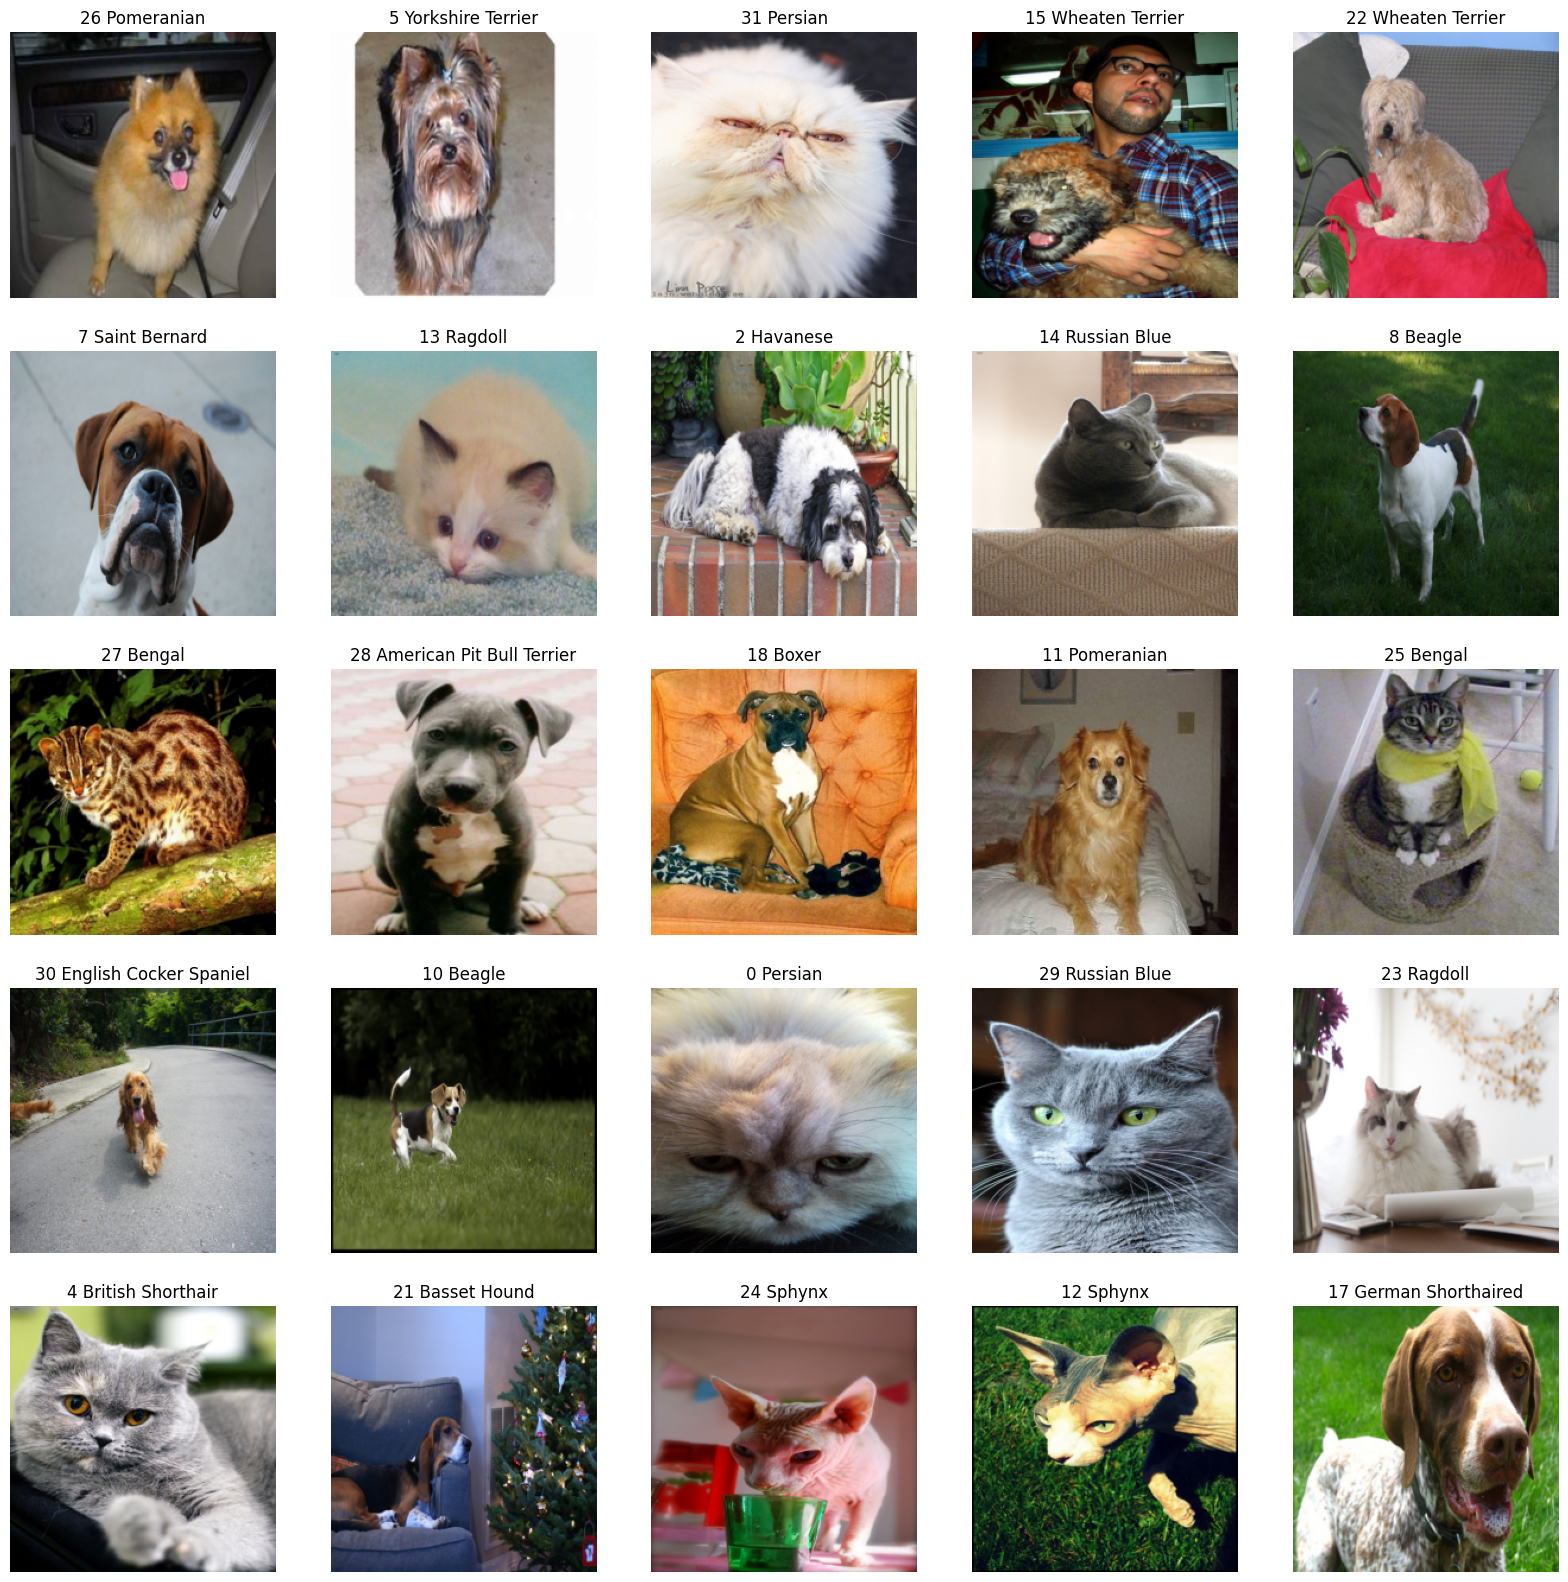

In [16]:
def denormalize(tensor):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    t = tensor.clone()
    for i, (m, s) in enumerate(zip(mean, std)):
        t[i] = t[i] * s + m
    return t.clamp(0, 1)

pltsize = 4
row_images = 5
col_images = 5
plt.figure(figsize=(col_images * pltsize, row_images * pltsize))

random_indices = random.sample(range(len(images)), row_images * col_images)

for i, i_rand in enumerate(random_indices):
    np_image = images.numpy()
    np_label = labels.numpy()
    plt.subplot(row_images, col_images, i + 1)
    plt.axis('off')
    plt.imshow(np.transpose(denormalize(images[i_rand]).numpy(), (1, 2, 0)))
    plt.title(str(i_rand) + " " + class_names[np_label[i_rand]])

plt.show()

### Task 2: Simple CNN
Create and evaluate a simple Alexnet-stlye small CNN to be trainined from scratch.

In [18]:
import math
import torch.nn.functional as F

In [19]:
class CNN(nn.Module):

    # Defining the Constructor
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=2, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        self.conv3 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(in_channels=512, out_channels=1024, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2)
        self.fc1 = nn.Linear(in_features=1024 * 14 * 14, out_features=1024)
        self.fc2 = nn.Linear(in_features=1024, out_features=num_classes)

    def forward(self, x):

        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))
        x = self.pool3(x)

        x = x.view(-1, 1024 * 14 * 14)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# Create an instance of the model class and allocate it to the device
model = CNN(num_classes=NUM_CLASSES)
model.to(DEVICE)
print(model)

CNN(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv5): Conv2d(512, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=200704, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=37, bias=True)
)


In [20]:
# Set the number of epochs to train for
epochs = 20
lr = 0.001

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Calcualte the number of min batches per epoch
n_steps_per_epoch = math.ceil(len(train_loader.dataset) / BATCH_SIZE)

# Define lists to store the training and validation loss and accuracy for each epoch
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Start training
for epoch in range(epochs):
    # Set the model to train mode
    model.train()

    # Initialize the training loss and accuracy for this epoch
    running_loss = 0.0
    running_corrects = 0
    val_running_loss = 0.0
    val_running_corrects = 0
    training_step = 0
    for x_train, y_train in train_loader:
        x_train, y_train = x_train.to(DEVICE), y_train.to(DEVICE)
        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(x_train)
        loss = criterion(outputs, y_train)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        # Compute statistics
        running_loss += loss.item() * BATCH_SIZE
        running_corrects += torch.sum(torch.argmax(outputs, dim=1) == y_train)
        metrics = {"train/train_loss": loss,
                   "train/epoch": (training_step + 1 + (n_steps_per_epoch * epoch)) / n_steps_per_epoch,
                   }

        training_step = training_step + 1
        del outputs
    # Compute statistics for the entire epoch
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = running_corrects.item() / len(train_loader.dataset) * 100

    metrics["train/train_acc"] =  epoch_acc

    # Append the training statistics to the lists
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    # Evaluation on validation set
    with torch.no_grad():
        for x_valid, y_valid in val_loader:
            x_valid, y_valid = x_valid.to(DEVICE), y_valid.to(DEVICE)
            val_outputs = model(x_valid)
            val_loss = criterion(val_outputs, y_valid)

            val_running_loss += val_loss.item() * BATCH_SIZE
            val_running_corrects += torch.sum(torch.argmax(val_outputs, dim=1) == y_valid)
            del val_outputs

    val_epoch_loss = val_running_loss / len(val_loader.dataset)
    val_epoch_acc = val_running_corrects.item() / len(val_loader.dataset) * 100

    val_losses.append(val_epoch_loss)
    val_accuracies.append(val_epoch_acc)

    print(f'Epoch {epoch+1}/{epochs}, Training Loss: {epoch_loss:.4f}, Training Accuracy: {epoch_acc:.2f}%, Validation Loss: {val_epoch_loss:.4f}, Validation Accuracy: {val_epoch_acc:.2f}%')

Epoch 1/20, Training Loss: 3.7690, Training Accuracy: 2.65%, Validation Loss: 3.6128, Validation Accuracy: 2.17%
Epoch 2/20, Training Loss: 3.6113, Training Accuracy: 2.89%, Validation Loss: 3.6136, Validation Accuracy: 2.04%
Epoch 3/20, Training Loss: 3.6110, Training Accuracy: 2.75%, Validation Loss: 3.6144, Validation Accuracy: 2.04%
Epoch 4/20, Training Loss: 3.6108, Training Accuracy: 2.82%, Validation Loss: 3.6148, Validation Accuracy: 2.04%
Epoch 5/20, Training Loss: 3.6108, Training Accuracy: 2.65%, Validation Loss: 3.6153, Validation Accuracy: 2.04%
Epoch 6/20, Training Loss: 3.6107, Training Accuracy: 2.45%, Validation Loss: 3.6160, Validation Accuracy: 2.04%
Epoch 7/20, Training Loss: 3.6106, Training Accuracy: 2.72%, Validation Loss: 3.6165, Validation Accuracy: 2.04%
Epoch 8/20, Training Loss: 3.6106, Training Accuracy: 2.51%, Validation Loss: 3.6170, Validation Accuracy: 2.04%
Epoch 9/20, Training Loss: 3.6105, Training Accuracy: 2.89%, Validation Loss: 3.6172, Validation

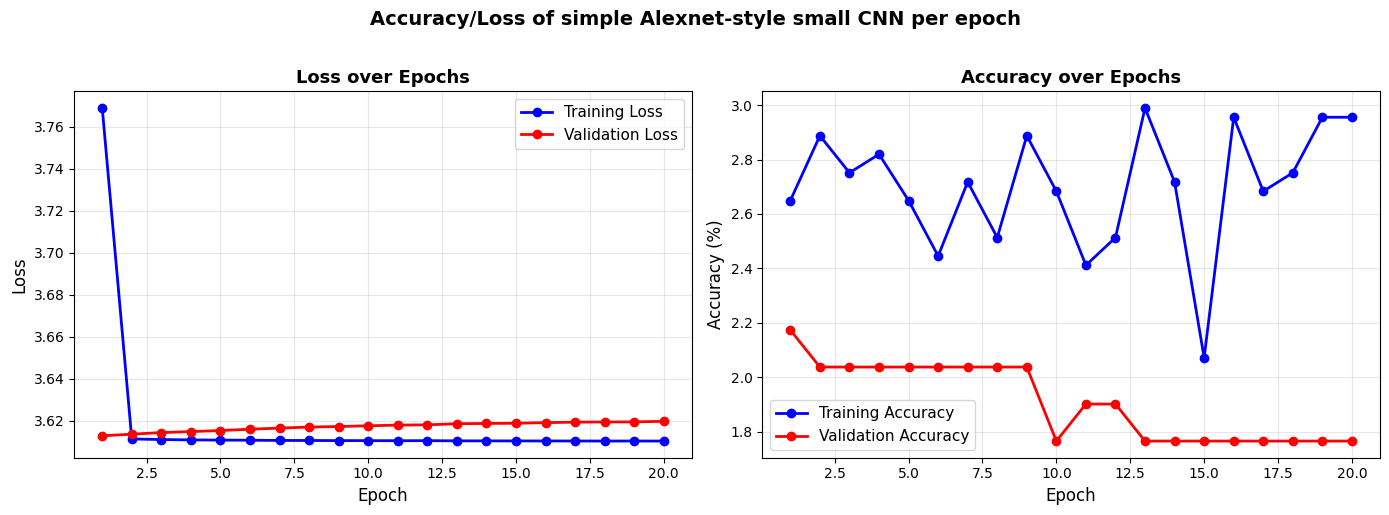

In [21]:
history = {
        'train_loss': train_losses,
        'train_acc': train_accuracies,
        'val_loss': val_losses,
        'val_acc': val_accuracies,
    }
visualize_training_history(history, "Accuracy/Loss of simple Alexnet-style small CNN per epoch")

### Task 3: Transfer Learning
Create and evaluate a model that uses an appropriate pre-trained network that can be fine-tuned to take advantage of transfer learning.

Load the ResMed18 models

In [20]:
pretrained_model = efficientnet_v2_l(weights=EfficientNet_V2_L_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/efficientnet_v2_l-59c71312.pth" to C:\Users\User/.cache\torch\hub\checkpoints\efficientnet_v2_l-59c71312.pth


100.0%


Freeze the weights of the pre-trained layers

In [21]:
for param in pretrained_model.parameters():
    param.requires_grad = False

Replace the fully connected layers.

In [22]:
input_size = pretrained_model.classifier[1].in_features

pretrained_model.classifier = nn.Sequential(
    nn.Linear(input_size, 4096),
    nn.ReLU(inplace=True),
    nn.Dropout(),
    nn.Linear(4096, 4096),
    nn.ReLU(inplace=True),
    nn.Dropout(),
    nn.Linear(4096, NUM_CLASSES)
)

pretrained_model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

Train and save the model

In [23]:
efficientnet_v2_l_pet_history = train(
    model=pretrained_model,
    model_name='efficientnet_v2_l_pet',
    criterion=torch.nn.CrossEntropyLoss(),
    optimizer=torch.optim.Adam(pretrained_model.parameters(), lr=0.001),
    num_epochs=25,
)

Starting training...

Epoch 1/25


RuntimeError: Parent directory trained_models does not exist.

Some visualisation

In [12]:
visualize_training_history(efficientnet_v2_l_pet_history, graph_title="Accuracy/Loss of efficientnet_v2_l per epoch ")

NameError: name 'efficientnet_v2_l_pet_history' is not defined

### Task 4: Data Augmentation
Modify the model created in Task 3 to use data augmentation to make the model more robust.

Create appropriate data transformations.

In [41]:
aug_image_transforms = torchvision.transforms.Compose([
    torchvision.transforms.Resize(IMAGE_SIZE),
    # Add transformers here
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

Create new data loaders using data augmentation for the training data.

In [42]:
# Load the combined train and validation split
aug_trainval_dataset = torchvision.datasets.OxfordIIITPet(
    root=DATA_DIR,
    split="trainval",
    target_types="category",   # 37 breed classes
    transform=aug_image_transforms,
    download=True,
)

aug_train_dataset, aug_val_dataset = torch.utils.data.random_split(
    aug_trainval_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

aug_train_loader = torch.utils.data.DataLoader(aug_train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS)
aug_val_loader   = torch.utils.data.DataLoader(aug_val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)

Visualise data augmentation examples.

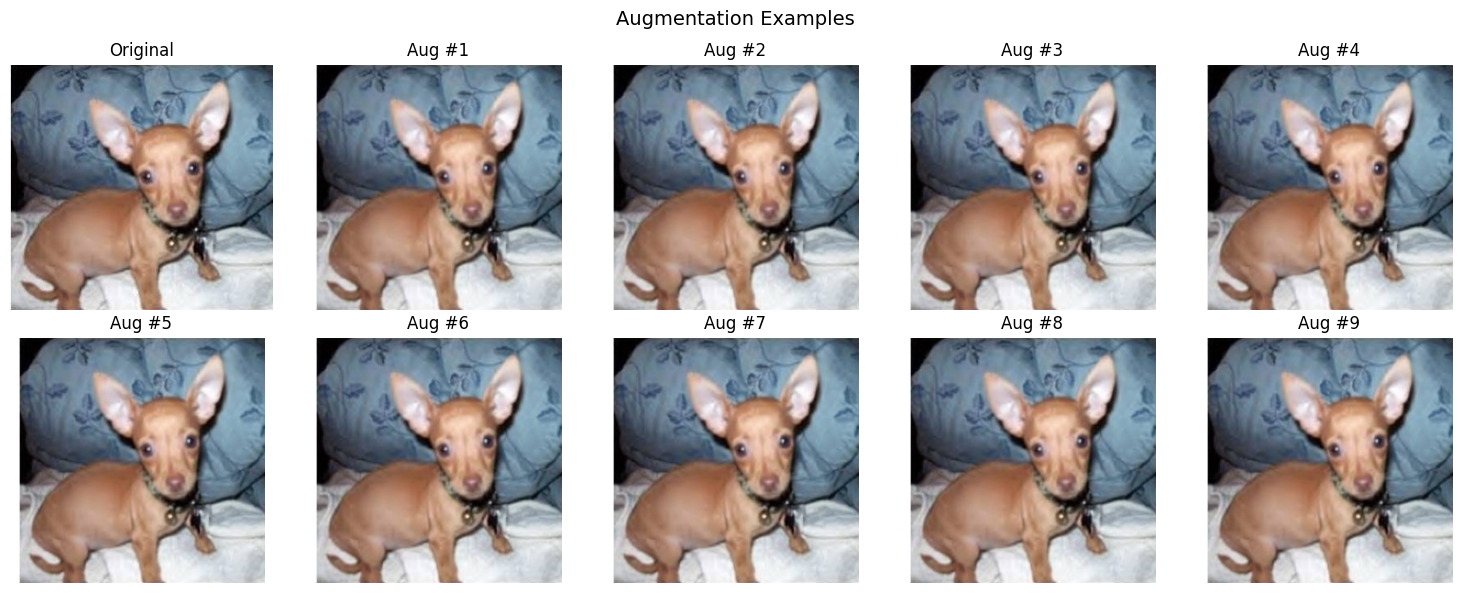

In [43]:
raw_ds = torchvision.datasets.OxfordIIITPet(DATA_DIR, split="trainval", target_types="category",
              transform=None, download=False)

raw_img, _ = raw_ds[random.randint(0, len(raw_ds))]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes[0, 0].imshow(raw_img)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

aug_only = torchvision.transforms.Compose(aug_image_transforms.transforms[:-2])  # skip ToTensor+Normalize
for i, ax in enumerate(axes.flatten()[1:], 1):
    ax.imshow(aug_only(raw_img))
    ax.set_title(f"Aug #{i}")
    ax.axis("off")

plt.suptitle("Augmentation Examples", fontsize=14)
plt.tight_layout()
plt.show()

Model training and evaluation.

In [16]:
# Add code here

### Task 5: Hierarchical Classification
This dataset has a natural hierarchy - pets can be divided into dog class and cat classes, before being classified into their more specific species. Based on the best performing approach from the previous tasks, create a hierarchical model that first classifies

In [17]:
# Add code here

### Task 6: Test Data Evaluation
Measure the perfomrance of the models trained using the test dataset.

In [44]:
images = []
labels = []

for image, label in test_loader:
    images.append(image.to(DEVICE))
    labels.append(label)

In [45]:
labels

[tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 tensor([0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 tensor([1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]),
 tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]),
 tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]),
 tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]),
 tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]

In [31]:
from sklearn import metrics
import pandas as pd
print("****** Test Data ********")

# Evaluate the model on the test set
model.eval()
test_outputs = model(x_test)
test_loss = criterion(test_outputs, y_test)
test_corrects = torch.sum(torch.argmax(test_outputs, dim=1) == y_test)
test_acc = test_corrects.item() / len(x_test) * 100

# Evaluate the model on the test set
model.eval()

# Make a set of predictions for the test data
y_pred = model(images)
y_pred = torch.argmax(y_pred, dim=1).cpu().numpy()

# Print performance details
print(metrics.classification_report(labels, y_pred, zero_division=1))

# Print confusion matrix
print("Confusion Matrix")
display(pd.crosstab(labels, y_pred, rownames=['True'], colnames=['Predicted'], margins=True))

****** Test Data ********


TypeError: conv2d() received an invalid combination of arguments - got (list, Parameter, Parameter, tuple, tuple, tuple, int), but expected one of:
 * (Tensor input, Tensor weight, Tensor bias = None, tuple of ints stride = 1, tuple of ints padding = 0, tuple of ints dilation = 1, int groups = 1)
      didn't match because some of the arguments have invalid types: (!list of [Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor

In [22]:
# Evaluate the model on the test set
model.eval()
y_pred = []

for x_test, y_test in test_loader:
    x_test, y_test = x_test.to(DEVICE), y_test.to(DEVICE)
    test_outputs = model(x_test)
    y_pred.append(test_outputs)

# Print performance details
print(metrics.classification_report(labels, y_pred, zero_division=1))

# Print confusion matrix
print("Confusion Matrix")
display(pd.crosstab(labels, y_pred, rownames=['True'], colnames=['Predicted'], margins=True))

OutOfMemoryError: CUDA out of memory. Tried to allocate 26.00 MiB. GPU 0 has a total capacity of 6.00 GiB of which 0 bytes is free. Of the allocated memory 12.02 GiB is allocated by PyTorch, and 473.95 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

### Task 7: Reflection
Write a short reflection on the models created in this notebook and your experiences and choices in making them.

The simple Alexnet-style CNN has performed poorly as compared to the pretrained model. This is most likely due to the fact that the pretrained model has been trained with more data and with more epochs (more time to train) allowing the learning of the model. During the training of the simple CNN, as per the Alexnet